In [ ]:
# We are building the model using cifar10 dataset
#We first use sigmoid fumction for building CNN
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from tensorflow.keras.utils import plot_model
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm

In [ ]:
#We use random seed value while creating training and test data set. 
#The goal is to make sure we get the same training and validation data set 
#while we use different hyperparameters or machine learning algorithms in order to assess the performance of different models.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


170508288/170498071 [==============================] - 2s 0us/step


In [ ]:
# we are splitting our data into training and testing set
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [ ]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) to one-hot vector
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [ ]:
# we are building our model
def define_model():
  #we are creating our CNN first layer along with hidden layer
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input,# we will see here whether the neurons are activated or not
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same')) # it is a convolutional operator for filtering windows of two dimensional input,# we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2))   # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
  
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input,# we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2)))  # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
 

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input,# we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
 
 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional 
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped
 

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be dropped



 model.add(Dense(class_num))
 model.add(Activation('sigmoid')) # we will have sigmoid activation function on last layer
  
#We are compiling our CNN model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

model = define_model()
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 367s 936ms/step - loss: 1.6830 - accuracy: 0.3802 - val_loss: 1.2385 - val_accuracy: 0.5477
Epoch 2/5
391/391 [==============================] - 369s 943ms/step - loss: 1.2091 - accuracy: 0.5659 - val_loss: 0.9850 - val_accuracy: 0.6489
Epoch 3/5
391/391 [==============================] - 367s 939ms/step - loss: 1.0027 - accuracy: 0.6456 - val_loss: 0.8571 - val_accuracy: 0.6918
Epoch 4/5
391/391 [==============================] - 367s 938ms/step - loss: 0.8797 - accuracy: 0.6915 - val_loss: 0.8107 - val_accuracy: 0.7161
Epoch 5/5
391/391 [==============================] - 368s 943ms/step - loss: 0.8083 - accuracy: 0.7185 - val_loss: 0.7488 - val_accuracy: 0.7353


In sigmoid we are taking 5 epochs and batch size =128 so we are getting accuracy 0.7353 and loss = 0.8083


Here cnn error is coming upto 26.47%

In [ ]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 26.47%


In [1]:
# we are using elu activation function for building the CNN
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers import Dropout
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [2]:
#We use random seed value while creating training and test data set. 
#The goal is to make sure we get the same training and validation data set 
#while we use different hyperparameters or machine learning algorithms in order to assess the performance of different models.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


170508288/170498071 [==============================] - 2s 0us/step


In [3]:
# we are splitting our data into training and testing set
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [4]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [5]:
#defining model
def define_model():
  #we are creating our CNN first layer along with hidden layer # we are creating the model as sequential
 model = Sequential()
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input, # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same')) # it is a convolutional operator for filtering windows of two dimensional input, # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2)))  
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
  
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input, # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input, # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional 
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed



 model.add(Dense(class_num))
 model.add(Activation('elu')) # last layer will have elu activation function
  
#We are compiling our CNN model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

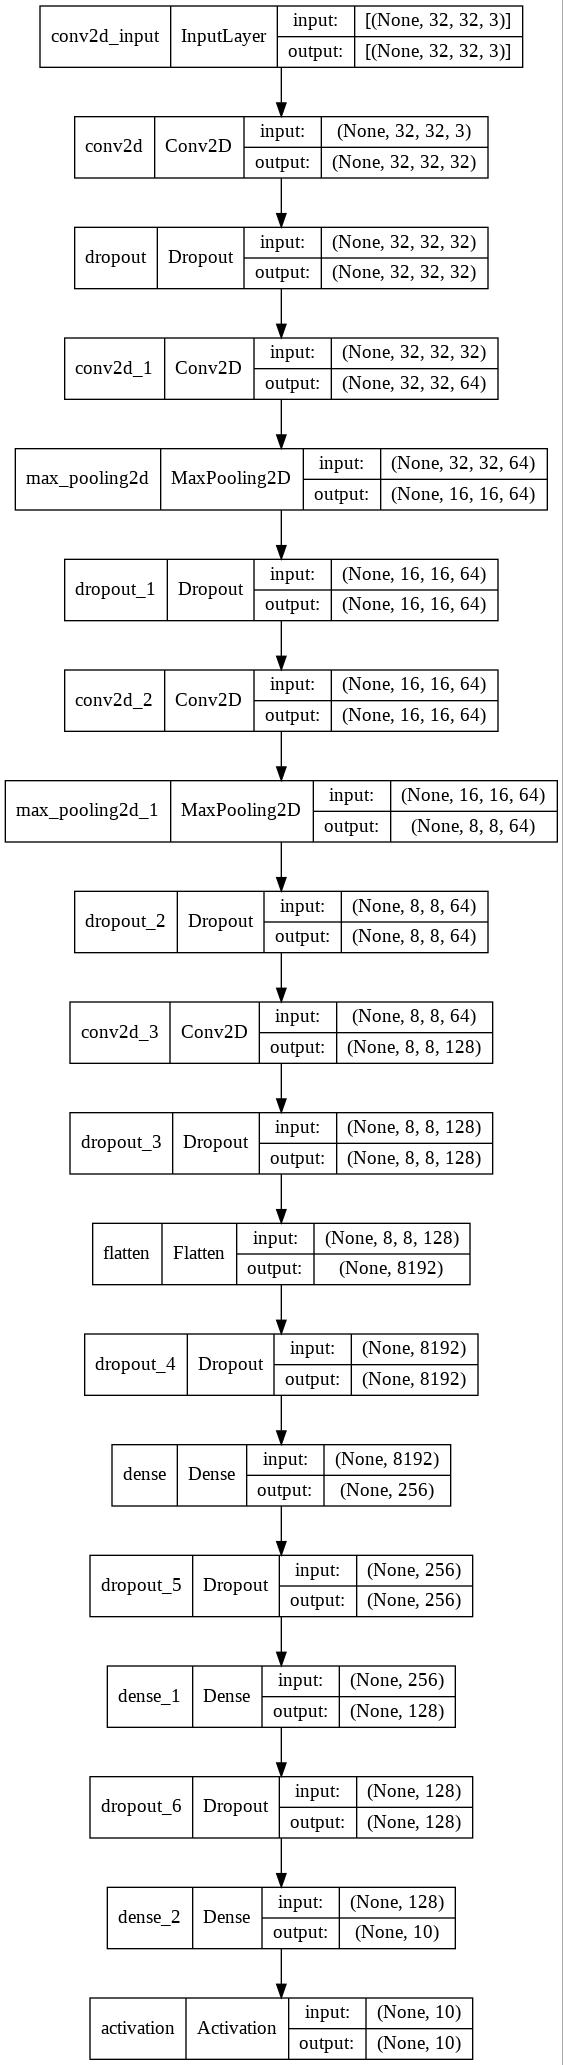

In [6]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 373s 950ms/step - loss: 3.5539 - accuracy: 0.1049 - val_loss: 2.3012 - val_accuracy: 0.1274
Epoch 2/5
391/391 [==============================] - 371s 949ms/step - loss: 2.2932 - accuracy: 0.1222 - val_loss: 2.2411 - val_accuracy: 0.1613
Epoch 3/5
391/391 [==============================] - 373s 955ms/step - loss: 2.2266 - accuracy: 0.1594 - val_loss: 2.0869 - val_accuracy: 0.2136
Epoch 4/5
391/391 [==============================] - 371s 949ms/step - loss: 2.2098 - accuracy: 0.1697 - val_loss: 2.1444 - val_accuracy: 0.2167
Epoch 5/5
391/391 [==============================] - 367s 938ms/step - loss: 2.1268 - accuracy: 0.2170 - val_loss: 2.0179 - val_accuracy: 0.2705


We are taking epochs =5 and batch size = 128 then we land up getting accuracy around 0.2705 and loss = 2.2168

we got cnn error =72.95%

In [ ]:
# this is the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 72.95%


In [7]:
# we are building our CNN using selu and importing required libraries
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from tensorflow.keras.utils import plot_model
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [8]:
#We use random seed value while creating training and test data set. 
#The goal is to make sure we get the same training and validation data set 
#while we use different hyperparameters or machine learning algorithms in order to assess the performance of different models.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


In [9]:
# we are splitting our model into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [10]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]


In [11]:
#defining model
def define_model():
 model = Sequential()  # we are creating the model as sequential
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input.  # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a convolutional operator for filtering windows of two dimensional input.  # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
  
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input.  # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input.  # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed



 model.add(Dense(class_num))
 model.add(Activation('selu'))
  
# we are compiling our CNN model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

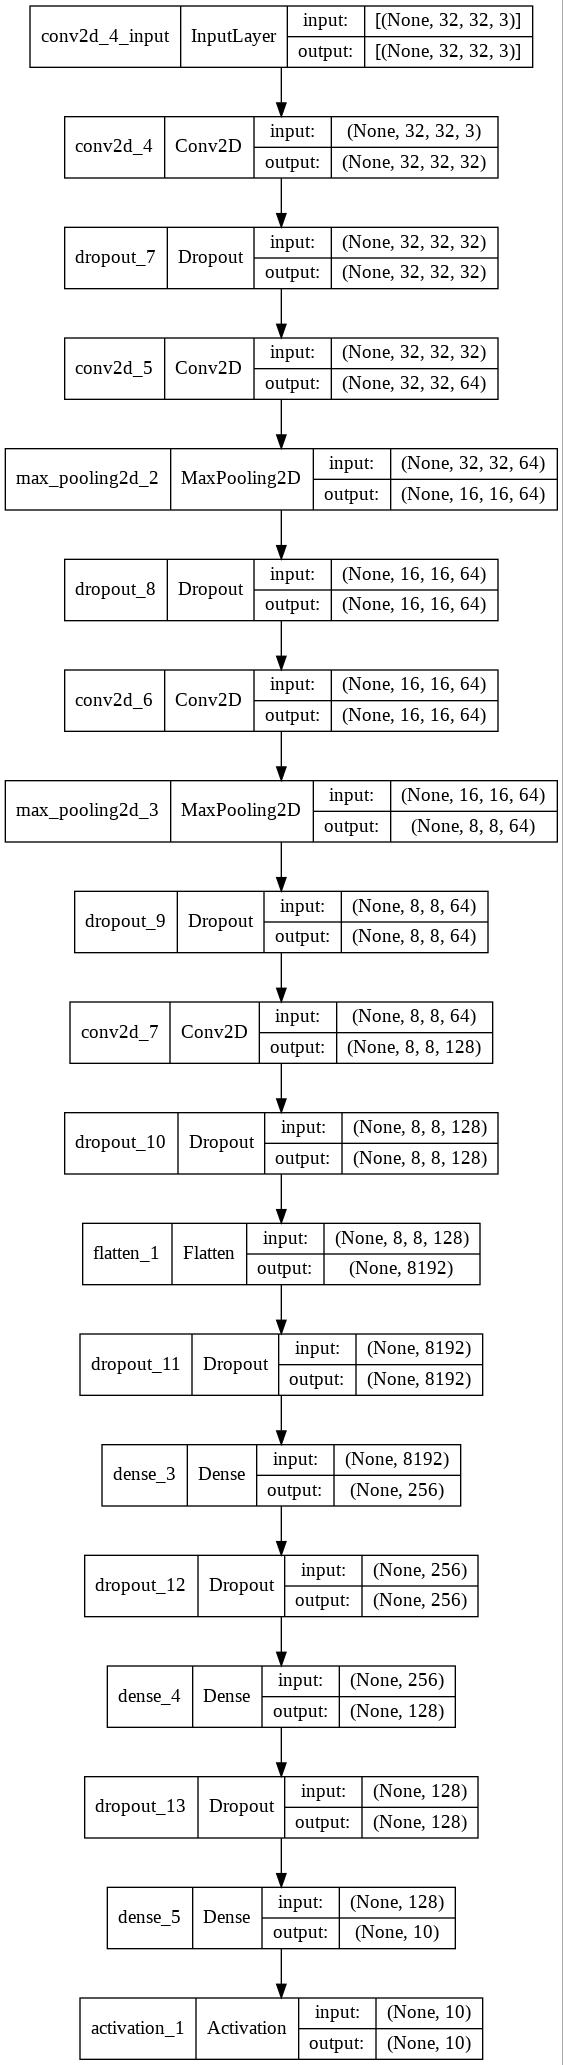

In [12]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 378s 963ms/step - loss: 4.8138 - accuracy: 0.1016 - val_loss: 3.5646 - val_accuracy: 0.1392
Epoch 2/5
391/391 [==============================] - 372s 952ms/step - loss: 3.7915 - accuracy: 0.1480 - val_loss: 3.5970 - val_accuracy: 0.0997
Epoch 3/5
391/391 [==============================] - 369s 943ms/step - loss: 3.4876 - accuracy: 0.1797 - val_loss: 3.3526 - val_accuracy: 0.2359
Epoch 4/5
391/391 [==============================] - 367s 938ms/step - loss: 3.4061 - accuracy: 0.2230 - val_loss: 3.2703 - val_accuracy: 0.2776
Epoch 5/5
391/391 [==============================] - 364s 931ms/step - loss: 3.6503 - accuracy: 0.2032 - val_loss: 3.3243 - val_accuracy: 0.2723


we take epochs = 5 and batch size = 128 and we end up getting accuracy = 0.2032 and loss = 3.6503 

our cnn model has 72.77% error

In [ ]:
# this is the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))


CNN Error: 72.77%


In [13]:
# we are building our model using relu activation function and importing the libraries
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers import Dropout
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm


In [14]:
#We use random seed value while creating training and test data set. 
#The goal is to make sure we get the same training and validation data set 
#while we use different hyperparameters or machine learning algorithms in order to assess the performance of different models.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()

In [15]:
# we are splitting the model into training and testing 
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0

In [16]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [17]:
#we are building the model
def define_model():
  #we are building the first CNN input layer and hidden layer
 model = Sequential()  # we are creating the model as sequential
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input. # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 # we are building second hidden layer and pooling the layer
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same')) # it is a convolutional operator for filtering windows of two dimensional input. # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2)))  # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
  
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input. # we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2)))  # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input. # we will see here whether the neurons are activated or not
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional 
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed



 model.add(Dense(class_num))
 model.add(Activation('relu'))
  
#we are compiling the model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model


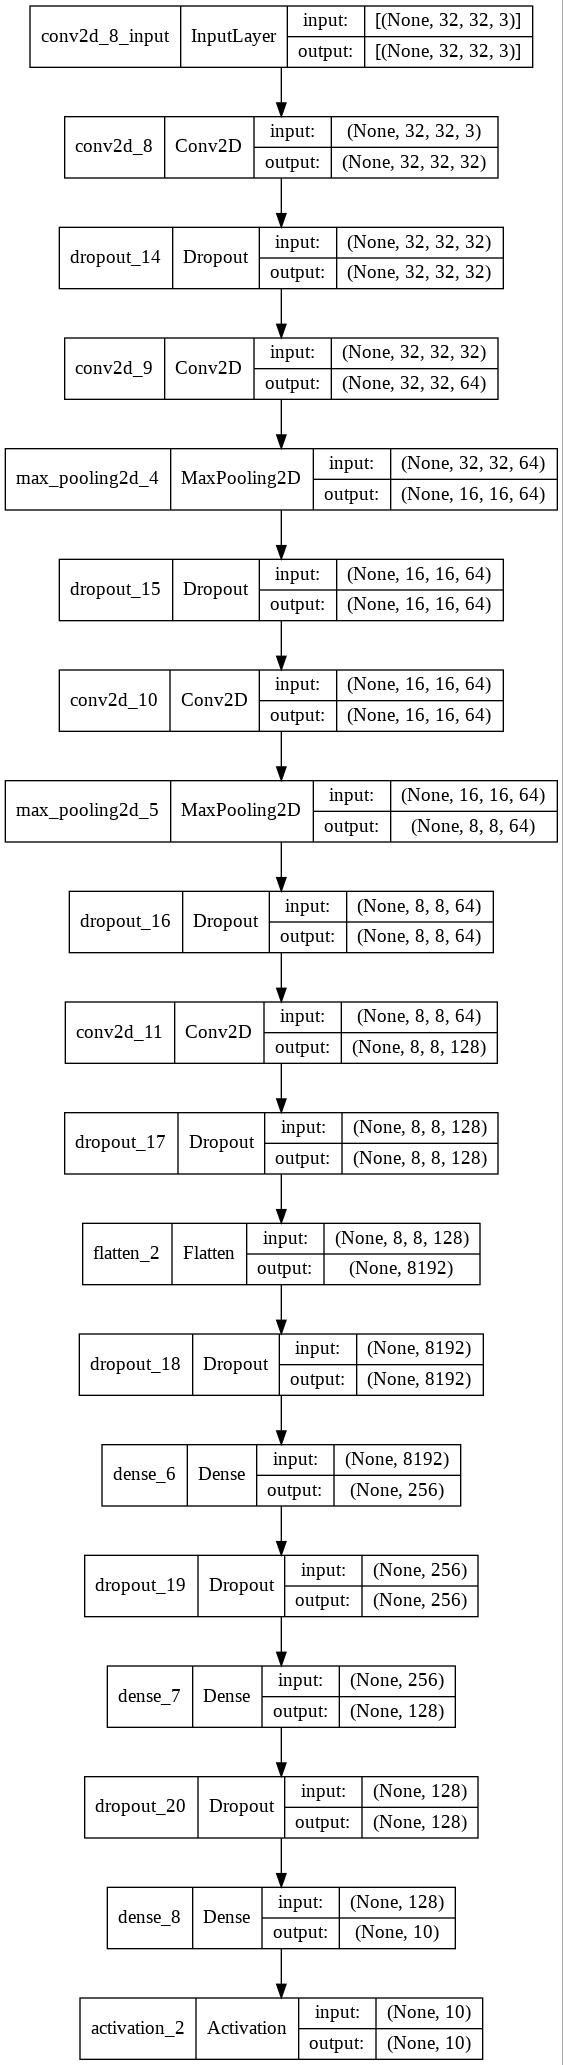

In [18]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model


In [ ]:
# we are training and evaluating the model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 385s 982ms/step - loss: 2.3768 - accuracy: 0.1468 - val_loss: 2.0635 - val_accuracy: 0.2542
Epoch 2/5
391/391 [==============================] - 382s 977ms/step - loss: 2.2198 - accuracy: 0.1696 - val_loss: 2.2756 - val_accuracy: 0.1536
Epoch 3/5
391/391 [==============================] - 399s 1s/step - loss: 2.2335 - accuracy: 0.1639 - val_loss: 2.2312 - val_accuracy: 0.1547
Epoch 4/5
391/391 [==============================] - 439s 1s/step - loss: 2.1877 - accuracy: 0.1783 - val_loss: 2.2546 - val_accuracy: 0.1439
Epoch 5/5
391/391 [==============================] - 357s 912ms/step - loss: 2.0724 - accuracy: 0.2298 - val_loss: 2.0596 - val_accuracy: 0.2405


we are taking 5 epochs and batch size 128 and we got accuracy 0.2298 and loss 2.07 

we got cnn error around 75.95%

In [ ]:
# this is the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 75.95%


In [19]:
#we are buiding the model using tanh
import numpy
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from tensorflow.keras.utils import plot_model
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.utils import np_utils
from keras.constraints import maxnorm

In [20]:
#We use random seed value while creating training and test data set. 
#The goal is to make sure we get the same training and validation data set 
#while we use different hyperparameters or machine learning algorithms in order to assess the performance of different models.
seed = 21
(X_train,y_train), (X_test,y_test) = cifar10.load_data()


In [21]:
# we are splitting the data into training and testing
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train=X_train / 255.0
X_test=X_test / 255.0


In [22]:
#np_utils. to_categorical is used to convert array of labeled data(from 0 to nb_classes - 1 ) 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
class_num = y_test.shape[1]


In [23]:
#defining model
def define_model():
  # we are creating the first input layer and hidden layer of CNN
 model = Sequential() # we are creating the model as sequential
 model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))) # it is a convolutional operator for filtering windows of two dimensional input.# we will see here whether the neurons are activated or not
 model.add(Dropout(0.2))

 # we are creating second hidden layer and pooling
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # it is a convolutional operator for filtering windows of two dimensional input.# we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
  
 model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input.# we will see here whether the neurons are activated or not
 model.add(MaxPooling2D((2, 2))) # it checks the maximum values and returns it into the array of smaller size
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))  # it is a convolutional operator for filtering windows of two dimensional input.# we will see here whether the neurons are activated or not
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 
 model.add(Flatten()) # it simplifies the array and coverts it into one dimensional 
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 model.add(Dense(256, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
 

 model.add(Dense(128, activation='relu', kernel_constraint=maxnorm(3))) # dense layers are regularly deeply connected neural network layers
 model.add(Dropout(0.2))  # we will drop out the weights in order to reduce the overfitting 20% weights will be removed



 model.add(Dense(class_num))
 model.add(Activation('tanh'))
  
# we are compiling our model
 model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 return model

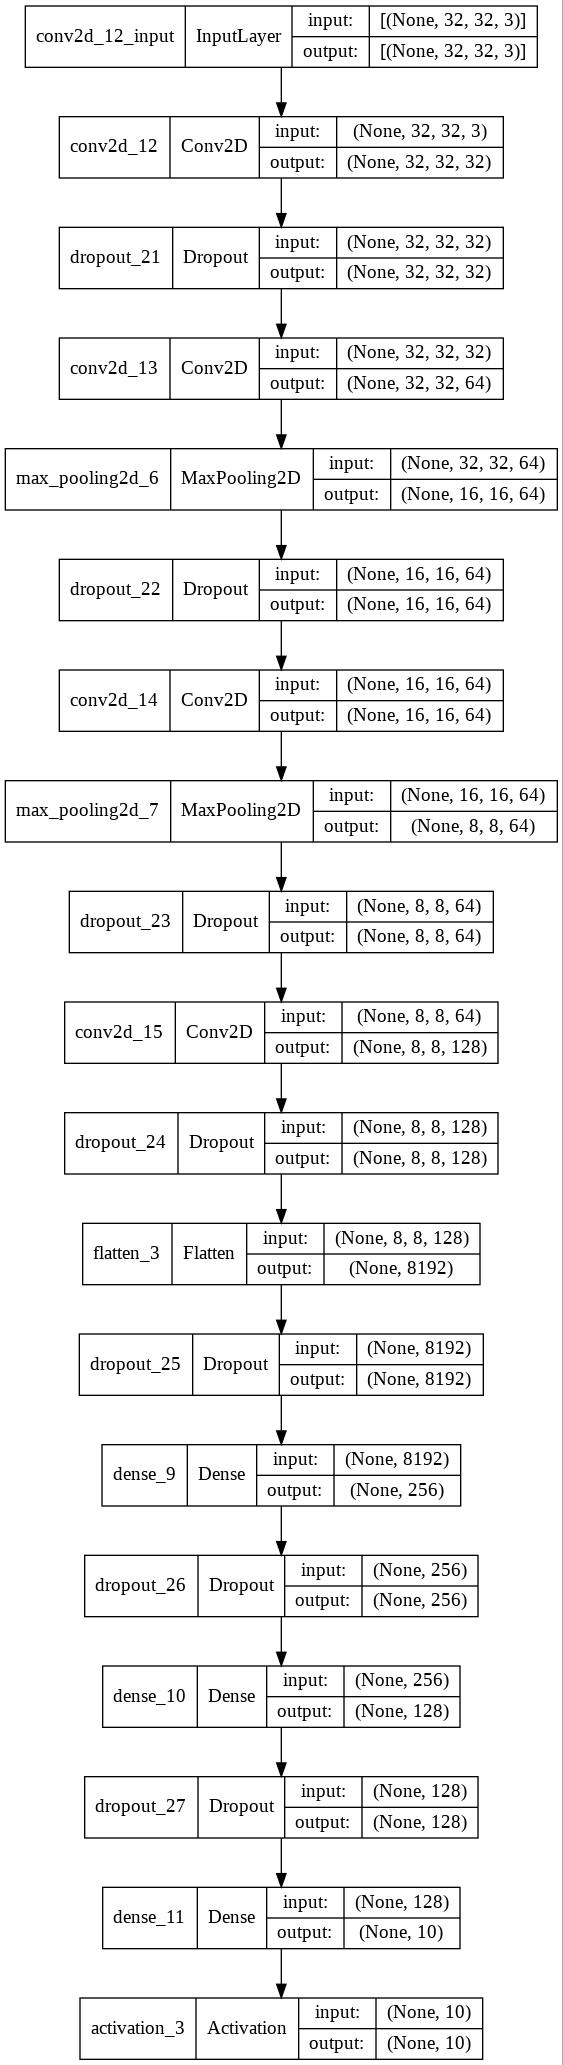

In [24]:
model = define_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model


In [ ]:
# we are training and evaluating our model
numpy.random.seed(seed)
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 5 , batch_size=128) 

Epoch 1/5
391/391 [==============================] - 363s 929ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 2/5
391/391 [==============================] - 367s 940ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 3/5
391/391 [==============================] - 363s 930ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 4/5
391/391 [==============================] - 368s 940ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000
Epoch 5/5
391/391 [==============================] - 365s 934ms/step - loss: nan - accuracy: 0.1000 - val_loss: nan - val_accuracy: 0.1000


we are giving 5 epochs and batch size 128 we git accuracy = 0.1000 and loss = nan

the cnn error is 90.00%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.00%
